In [1]:
import graph_tool.all as gt

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
import pandas as pd

In [38]:
df = pd.read_csv("test_files/HUVEC_chr2.csv")

In [42]:
df = df[df["spar_alpha"]<0.15]

In [43]:
df

,bin1_id,bin2_id,count,exp_ratio,spar_alpha
54,24897,26443,1,1.000000,0.1142
55,24897,26464,1,1.000000,0.1142
56,24897,26467,1,1.000000,0.1142
70,24897,27401,1,1.000000,0.0892
103,24897,24932,3,1.321928,0.1142
...,...,...,...,...,...
7783337,49093,49102,12,1.765535,0.1247
7783353,49094,49099,23,2.099536,0.1431
7783371,49095,49106,15,2.247928,0.1255
7783375,49095,49104,7,1.263034,0.1155


In [41]:
bin_ids = np.union1d(df["bin1_id"].unique(), df["bin2_id"].unique())
bin_ids = np.sort(bin_ids)
bin_dic = {"bin_ids": bin_ids, "node_id": np.arange(0, len(bin_ids))}
bin_ind = pd.DataFrame(bin_dic)
print(bin_ind)

       bin_ids  node_id
0        24897        0
1        24898        1
2        24899        2
3        24900        3
4        24901        4
...        ...      ...
23758    49108    23758
23759    49109    23759
23760    49110    23760
23761    49111    23761
23762    49112    23762

[23763 rows x 2 columns]


In [8]:
edge_list = df.merge(bin_ind, how="left", left_on="bin1_id", right_on="bin_ids")
edge_list = edge_list.merge(bin_ind, how="left", left_on="bin2_id", right_on="bin_ids")
edge_list.drop(["bin_ids_x", "bin_ids_y"], axis=1, inplace=True)
edge_list

,bin1_id,bin2_id,count,exp_ratio,spar_alpha,node_id_x,node_id_y
0,24897,27401,1,1.000000,0.0892,0,1812
1,24898,25581,1,1.000000,0.0986,1,445
2,24898,25597,1,1.000000,0.0930,1,456
3,24899,25321,1,1.000000,0.0615,2,288
4,24899,25488,2,1.584963,0.0817,2,395
...,...,...,...,...,...,...,...
21379,49043,49062,7,1.736966,0.0996,16695,16710
21380,49043,49080,3,1.321928,0.0861,16695,16726
21381,49043,49066,3,1.000000,0.0974,16695,16713
21382,49090,49103,7,1.459432,0.0977,16734,16744


In [9]:
edge_list.dtypes

bin1_id         int64
bin2_id         int64
count           int64
exp_ratio     float64
spar_alpha    float64
node_id_x       int64
node_id_y       int64
dtype: object

In [10]:
to_keep = ["exp_ratio"]
cols_to_keep = ["node_id_x", "node_id_y", "bin1_id", "bin2_id"] + list(to_keep)
cols_to_keep

['node_id_x', 'node_id_y', 'bin1_id', 'bin2_id', 'exp_ratio']

In [14]:
edge_list.drop([col for col in edge_list.columns.tolist() if col not in cols_to_keep], axis=1, inplace=True)
print(edge_list)

       bin1_id  bin2_id  exp_ratio  node_id_x  node_id_y
0        24897    27401   1.000000          0       1812
1        24898    25581   1.000000          1        445
2        24898    25597   1.000000          1        456
3        24899    25321   1.000000          2        288
4        24899    25488   1.584963          2        395
...        ...      ...        ...        ...        ...
21379    49043    49062   1.736966      16695      16710
21380    49043    49080   1.321928      16695      16726
21381    49043    49066   1.000000      16695      16713
21382    49090    49103   1.459432      16734      16744
21383    49091    49109   0.736966      16735      16748

[21384 rows x 5 columns]


In [23]:
node_id_cols = ["node_id_x", "node_id_y"]
annot_cols = [c for c in edge_list.columns.tolist() if c not in node_id_cols]

In [26]:
edge_list = edge_list[node_id_cols + annot_cols]
edge_list

,node_id_x,node_id_y,bin1_id,bin2_id,exp_ratio
0,0,1812,24897,27401,1.000000
1,1,445,24898,25581,1.000000
2,1,456,24898,25597,1.000000
3,2,288,24899,25321,1.000000
4,2,395,24899,25488,1.584963
...,...,...,...,...,...
21379,16695,16710,49043,49062,1.736966
21380,16695,16726,49043,49080,1.321928
21381,16695,16713,49043,49066,1.000000
21382,16734,16744,49090,49103,1.459432


In [57]:
g = gt.Graph()
edge_props = [g.new_edge_property("long double") for ann in annot_cols]

In [56]:
edge_list.dtypes["node_id_y"].str

'<i8'

In [ ]:
g = gt.Graph()

In [3]:
g = gt.load_graph("huvec_chr2_15.xml")
g

<Graph object, undirected, with 23643 vertices and 128437 edges, 1 internal vertex property, 1 internal edge property, at 0x7fe2941a5410>

In [4]:
g.list_properties()

_graphml_vertex_id     (vertex)  (type: string)
_graphml_edge_id       (edge)    (type: string)


In [7]:
g.vp._graphml_vertex_id[]

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'slice'

In [28]:
vals, bins = gt.vertex_hist(g, "total")

(array([ 0.        ,  0.        ,  8.20457114,  8.93663794,  9.53332973,
        10.17617315, 10.54882191, 10.6926155 , 10.83683936, 10.95782756,
        10.84392105, 10.83368075, 10.65463603, 10.47978026, 10.21188829,
        10.04984855,  9.77971936,  9.43462823,  9.23361968,  8.88569637,
         8.58871464,  8.38801729,  8.01122726,  7.88264305,  7.53138146,
         7.15987134,  6.71424552,  6.96578428,  6.67242534,  6.08746284,
         6.28540222,  5.80735492,  5.42626475,  5.64385619,  4.64385619,
         4.80735492,  5.        ,  3.80735492,  4.52356196,  4.        ,
         4.24792751,  3.        ,  3.70043972,  3.32192809,  3.32192809,
         3.70043972,  3.        ,  1.5849625 ,  3.169925  ,  2.5849625 ,
         2.5849625 ,  2.32192809,  2.80735492,  1.5849625 ,  3.        ,
         1.5849625 ,  0.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         2.        ,  0.        ,  0.        ,  0. 

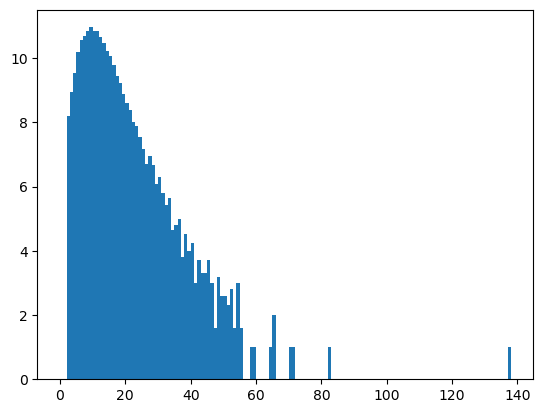

In [26]:
plt.hist(bins[1:], bins, weights=log2(vals+1))

In [29]:
stat_mean, stat_std = gt.vertex_average(g, "total")

In [32]:
stat_mean, stat_std

(10.86469568159709, 0.04232660051113368)

In [13]:
2.940e+02

294.0

(array([1523., 6135., 7260., 4549., 2148., 1010.,  471.,  241.,  131.,
          75.]),
 array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40.]),
 <BarContainer object of 10 artists>)

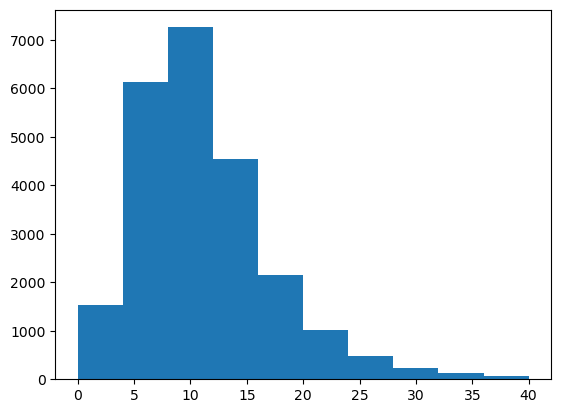

In [12]:
degs = g.get_total_degrees(g.get_vertices()).tolist()
plt.hist(degs, range=(0, 40))

In [13]:
g2 = gt.Graph(g)
g2

<Graph object, undirected, with 23643 vertices and 128437 edges, 1 internal vertex property, 1 internal edge property, at 0x7f6e18583cd0>

In [15]:
gt.random_rewire(g2)

207

(array([1523., 6135., 7260., 4549., 2148., 1010.,  471.,  241.,  131.,
          75.]),
 array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40.]),
 <BarContainer object of 10 artists>)

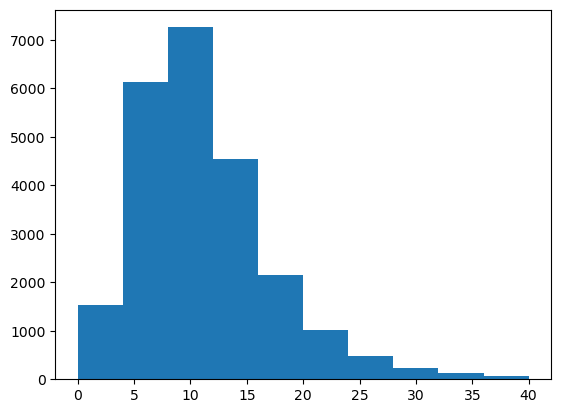

In [20]:
degs2 = g2.get_total_degrees(g2.get_vertices()).tolist()
plt.hist(degs2, range=(0, 40))

In [33]:
g2.get_total_degrees(g2.get_vertices()) == g.get_total_degrees(g.get_vertices())

array([ True,  True,  True, ...,  True,  True,  True])

In [30]:
g.get_vertices() == g2.get_vertices()

array([ True,  True,  True, ...,  True,  True,  True])

In [38]:
small = gt.load_graph("huvec_chr2_05.xml")
small_degs = small.get_total_degrees(small.get_vertices())
mask = small.new_vp("bool", vals=small_degs > 2)
small.set_vertex_filter(mask)
small

<Graph object, undirected, with 46 vertices and 3 edges, 1 internal vertex property, 1 internal edge property, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x7f6e181ea810, at 0x7f6e0b99e650>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x7f6e181ea810, at 0x7f6e13fe5790>, False), at 0x7f6e181ea810>

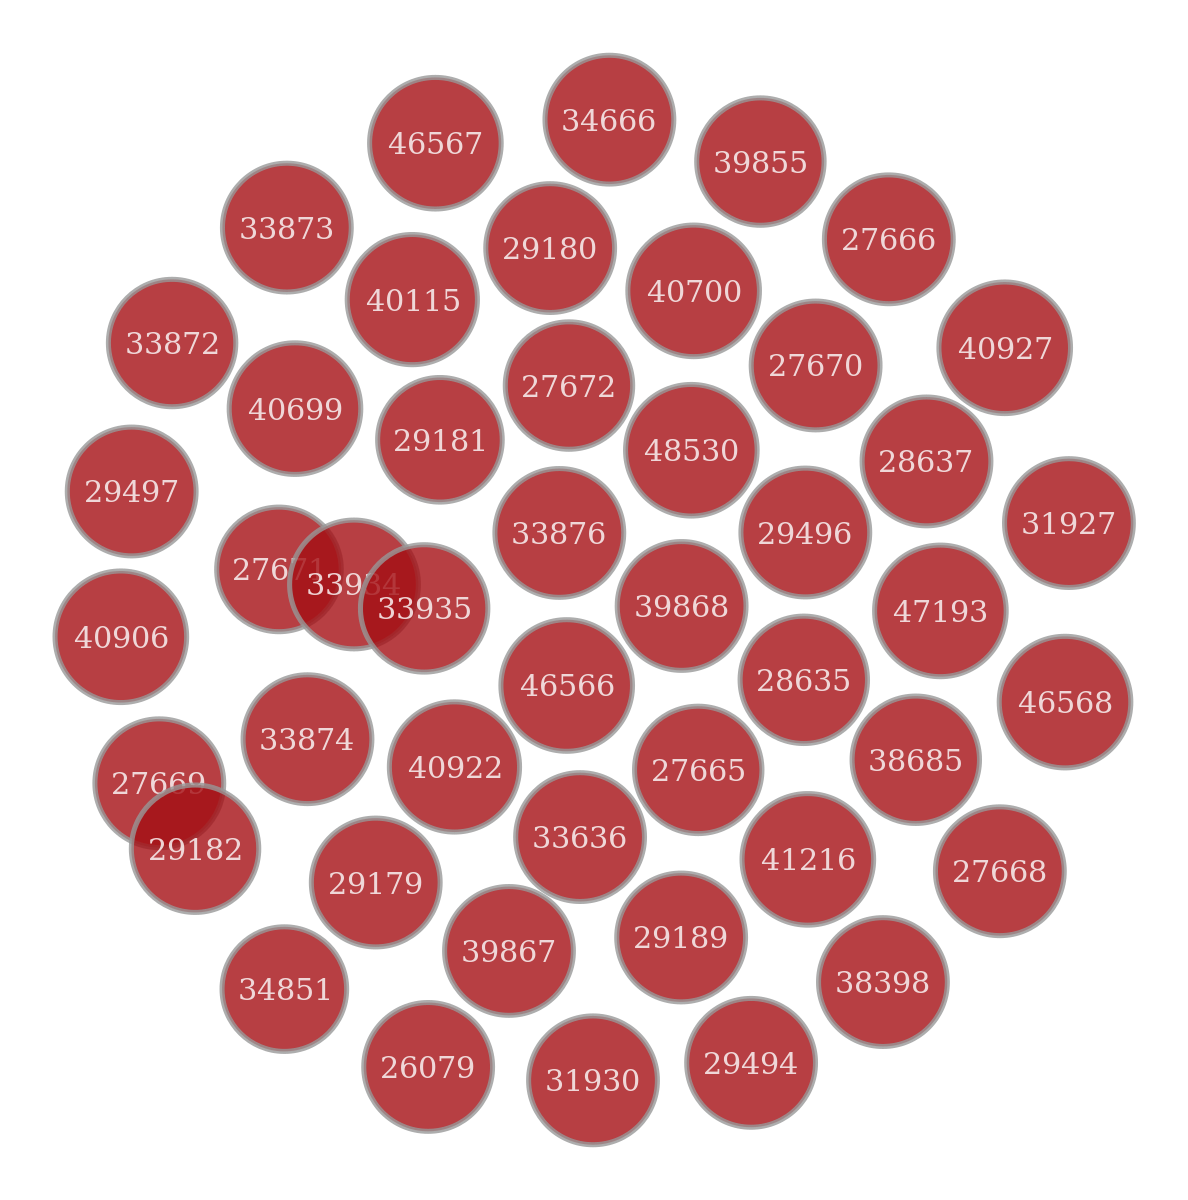

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f6e181ea810, at 0x7f6e0ba96a90>

In [40]:
gt.graph_draw(small, vertex_text=small.vp["_graphml_vertex_id"])

In [41]:
small2 = gt.Graph(small)
small2

<Graph object, undirected, with 46 vertices and 3 edges, 1 internal vertex property, 1 internal edge property, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x7f6e18cc3950, at 0x7f6e1829c310>, False), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x7f6e18cc3950, at 0x7f6e0badf110>, False), at 0x7f6e18cc3950>

In [69]:
import random
old_names = list(small.vp["_graphml_vertex_id"])
new_names = list(small.vp["_graphml_vertex_id"])
random.shuffle(new_names)

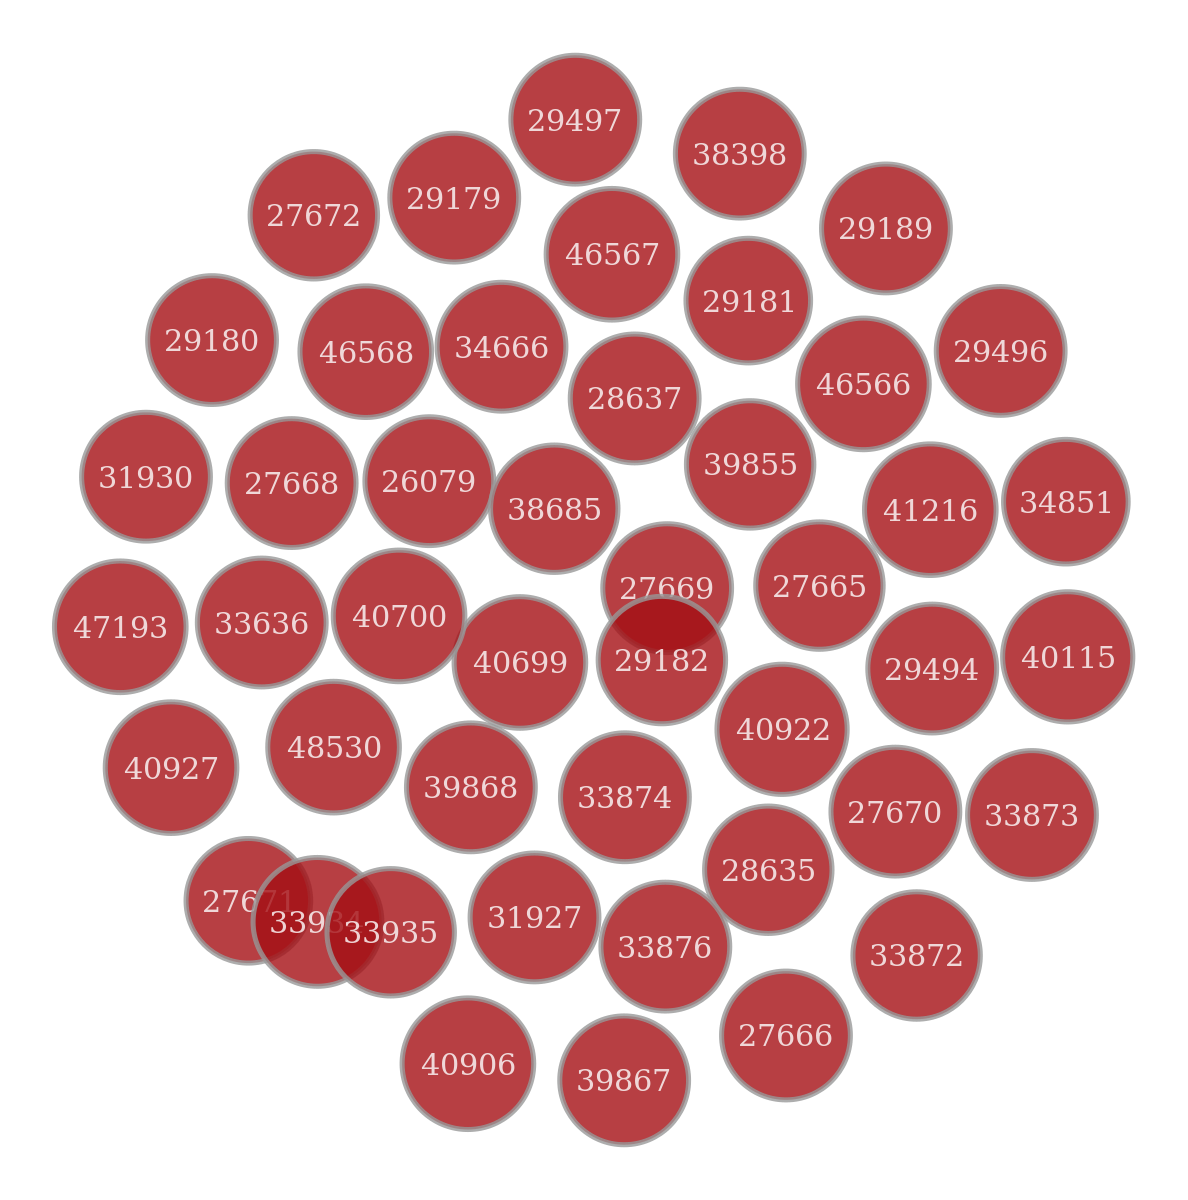

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f6e181ea810, at 0x7f6e0b99cc50>

In [67]:
node_names = small.new_vp("string", vals=old_names)
gt.graph_draw(small, vertex_text=node_names)

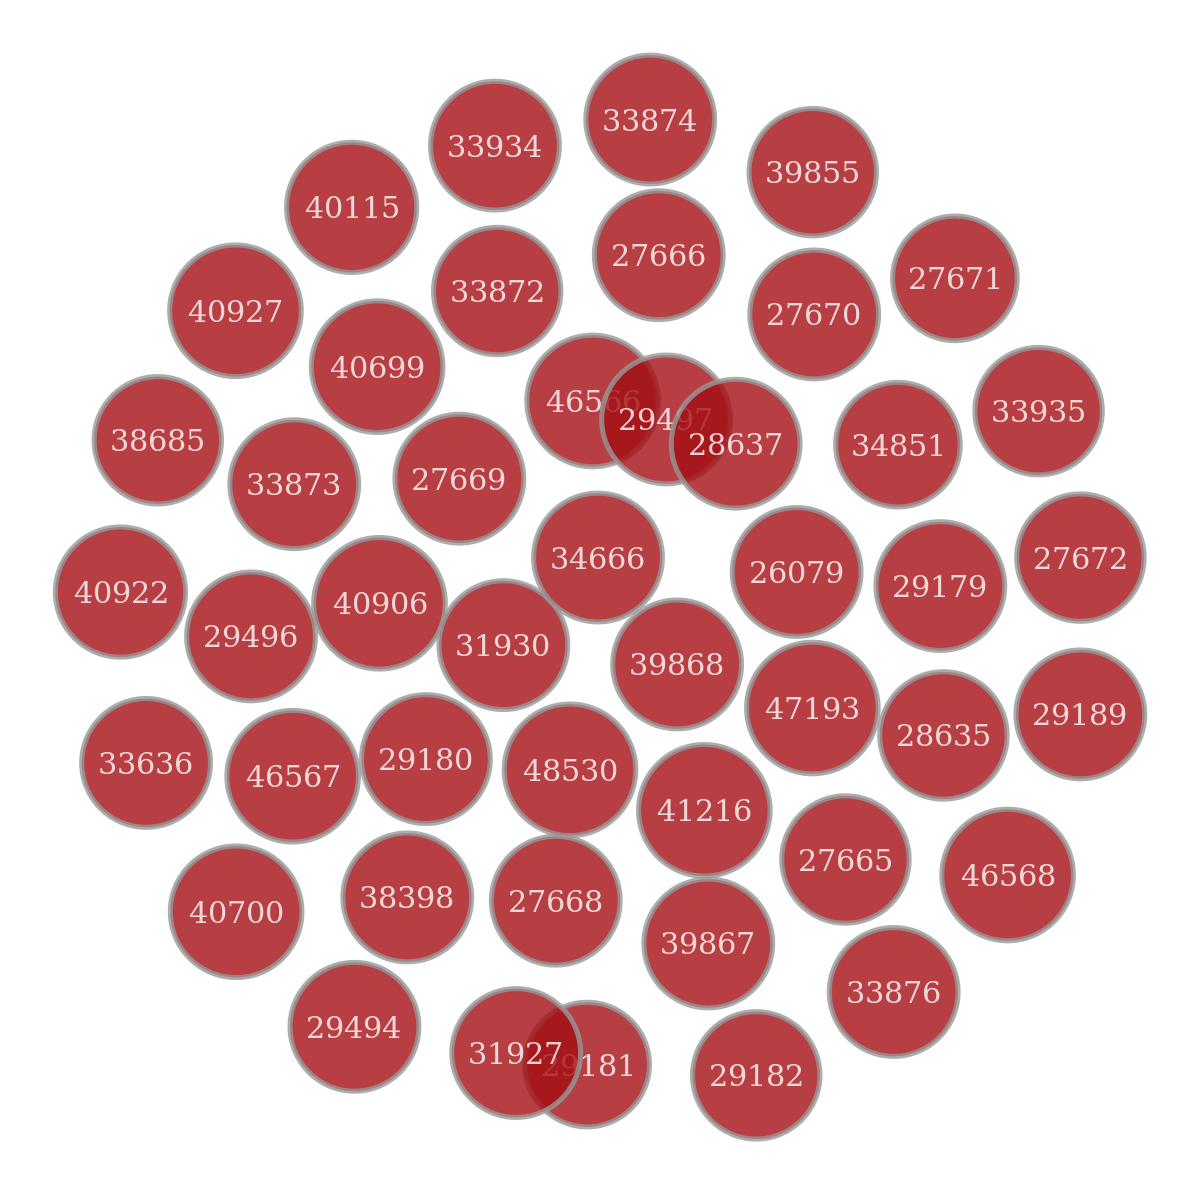

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f6e181ea810, at 0x7f6e0bd23110>

In [70]:
node_names = small.new_vp("string", vals=new_names)
gt.graph_draw(small, vertex_text=node_names)

In [73]:
to_keep = old_names[:15]
mask = small.new_vp("bool", vals = [True if i in to_keep else False for i in list(node_names)])
# g.set_edge_filter(mask)

15

In [58]:
list(new_names)

['',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']